# Imports

In [306]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import pydicom
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [307]:
#seed used for random
seed = 42
torch.manual_seed(seed)

# Loading measurement data

In [308]:
#read csv
df = pd.read_csv("../data/measurements.csv")

print(df.columns)

#drop unnecessary columns
df.drop(columns = ["Student Name", "Notes", "Unnamed: 23", "Unnamed: 24", "Unnamed: 25", "Unnamed: 26"], inplace = True)

print(df.columns)

print(len(df.columns.values))

Index(['Student Name', 'ID', 'L Medial Cortical Thickness',
       'L Lateral Cortical Thickness ', 'L Shaft Width',
       'L Femoral Head Diameter', 'L Horizontal Offset', 'L Vertical Offset',
       'L Femoral Neck Width', 'L Hip Axis Length',
       'L Femoral Neck Axis Length', 'L Femoral Neck-Shaft  Angle',
       'R Medial Cortical Thickness', 'R Lateral Cortical Thickness ',
       'R Shaft Width', 'R Femoral Head Diameter', 'R Horizontal Offset',
       'R Vertical Offset', 'R Femoral Neck Width', 'R Hip Axis Length',
       'R Femoral Neck Axis Length', 'R Femoral Neck-Shaft  Angle', 'Notes',
       'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26'],
      dtype='object')
Index(['ID', 'L Medial Cortical Thickness', 'L Lateral Cortical Thickness ',
       'L Shaft Width', 'L Femoral Head Diameter', 'L Horizontal Offset',
       'L Vertical Offset', 'L Femoral Neck Width', 'L Hip Axis Length',
       'L Femoral Neck Axis Length', 'L Femoral Neck-Shaft  Angle',
       '

In [309]:
#get rid of images with na (only temporary for convenience)
df = df.dropna()

# Load image data (augmentation, datasets, and dataloaders)

In [310]:
#image directory
img_dir = "../data/box_images"

#train test split
train_test_split = 0.8

#batch size
train_batch_size = 128
test_batch_size = 8

#pixels per mm conversion (known)
pix_per_mm = 2400 / 408

#training scale factor
img_scale_factor = 0.1

#image size (pix)
img_width = int(2400 * img_scale_factor)
img_height = int(1920 * img_scale_factor)

In [311]:
#data augmentation settings
##rotation
rot_int = 30
rot_st = 0
rot_en = 360 - rot_int

##down scale
scale_int = 0.1
scale_st = 0.7
scale_en = 1 #TODO can change this, 0.6 was chosen so no matter what rotation, no part of image is cut off

##random background color
rand_bg = True

In [312]:
# #####FIXME STRICTLY TESTING FIXME#####
# rot_int = 30
# rot_st = 0
# rot_en = 0

# scale_int = 0.1
# scale_st = 1
# scale_en = 1

In [313]:
#class for each data point: image path, flip (if asking for left side of image), rotation, scale, true values for measurements
class DataPoint:
    def __init__(self, img_dir, img_file, img_flip, df, img_width, img_height, aug_rot = 0, aug_scale = 1, aug_rand_bg = False):
        self.img_path = img_dir + '/' + img_file
        self.img_flip = img_flip
        self.img_width = img_width
        self.img_height = img_height
        self.aug_rot = aug_rot
        self.aug_scale = aug_scale
        self.aug_rand_bg_val = np.random.rand() if aug_rand_bg else 0
        self.y = torch.from_numpy(df.loc[df['ID'] == img_file].drop(columns = 'ID').values.astype(np.float32)).reshape(-1)

        #additionally required aug_scale given aug_rot
        abscos = np.abs(np.cos(self.aug_rot * np.pi / 180))
        abssin = np.abs(np.sin(self.aug_rot * np.pi / 180))
        self.aug_scale *= min(1 / (abscos + self.img_height / self.img_width * abssin), 1 / (self.img_width / self.img_height * abssin + abscos))
    
    #apply augmentation, return augmented image and rescaled values for measurements
    def get_image(self):
        ds = pydicom.dcmread(self.img_path)
        img = ds.pixel_array

        img = torch.from_numpy(img).float()
        img = (img - img.min()) / (img.max() - img.min() + 1e-5)
        img = img.unsqueeze(0).unsqueeze(0)

        #flip image if needed
        if self.img_flip:
            img = TF.hflip(img)

        #downscale image
        new_height = int(self.img_height * self.aug_scale)
        new_width = int(self.img_width * self.aug_scale)
        img = F.interpolate(img, size = (new_height, new_width), mode = 'bilinear', align_corners = False)

        #pad back to target size
        pad_height = self.img_height - new_height
        pad_width = self.img_width - new_width
        pad_u = pad_height // 2
        pad_d = pad_height - pad_u
        pad_l = pad_width // 2
        pad_r = pad_width - pad_l
        img = F.pad(img, (pad_l, pad_r, pad_u, pad_d), mode = 'constant', value = self.aug_rand_bg_val)

        #rotate image
        img = TF.rotate(img, angle = self.aug_rot, interpolation = TF.InterpolationMode.BILINEAR, fill = self.aug_rand_bg_val)

        #get measurements for correct side, rescale all measurements so they are in terms of pixels (except for angle measurement)
        y_aug = self.y.clone()
        if self.img_flip: #left side of image, right set of measurements
            y_aug = y_aug[10:]
        else: #right side of image, left set of measurements
            y_aug = y_aug[:10]
        y_aug[:9] *= self.aug_scale

        return img.squeeze(0), y_aug, torch.tensor(self.aug_scale).float()


In [314]:
class ImageDataset(Dataset):
    def __init__(self, data_points):
        self.data_points = data_points

    def __len__(self):
        return len(self.data_points)

    def __getitem__(self, idx):
        return self.data_points[idx].get_image()

In [315]:
#all images in directory
all_img_in_dir = [i for i in os.listdir(img_dir) if i.lower().endswith("dcm")]

#check all images in df are loaded (else throw error)
for i in df['ID'].values:
    if i not in all_img_in_dir:
        raise SystemError(f'Directory is missing images: {i}')
    
#load only images in the df
all_img = [i for i in all_img_in_dir if i in df['ID'].values]
print(f'Images in use: {len(all_img)}/{len(all_img_in_dir)}')

#split train and test sets
all_idx = torch.randperm(len(all_img))
train_img = [all_img[i] for i in all_idx[:int(train_test_split * len(all_img))]]
test_img = [all_img[i] for i in all_idx[int(train_test_split * len(all_img)):]]

Images in use: 162/3094


In [316]:
#augmented training data in DataPoint class
train_data_points = []
for img_file in train_img:
    for img_flip in range(2):
        for aug_rot in np.arange(rot_st, rot_en + 1e-8, rot_int):
            for aug_scale in np.arange(scale_st, scale_en + 1e-8, scale_int):
                train_data_points.append(DataPoint(img_dir, img_file, img_flip, df, img_width, img_height, aug_rot, aug_scale, rand_bg))
print(f'Augmented training set size: {len(train_data_points)}')

#testing data in DataPoint class (no augmentation transformations applied)
test_data_points = []
for img_file in test_img:
    for img_flip in range(2):
        test_data_points.append(DataPoint(img_dir, img_file, img_flip, df, img_width, img_height, 0, 1, False))
print(f'Testing set size: {len(test_data_points)}')

Augmented training set size: 12384
Testing set size: 66


In [317]:
#training dataset and data loader
train_set = ImageDataset(train_data_points)
train_loader = DataLoader(train_set, batch_size = train_batch_size, shuffle = True)

#testing dataset and data loader
test_set = ImageDataset(test_data_points)
test_loader = DataLoader(test_set, batch_size = test_batch_size, shuffle = False)

torch.Size([1, 192, 240])
torch.Size([128, 10])
torch.Size([128])
tensor(0.7200)


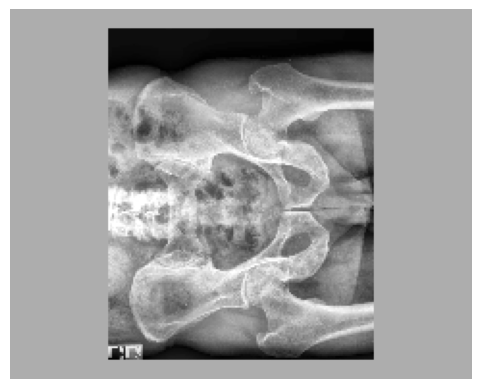

In [318]:
#quick test
for imgs, ys, aug_scales in train_loader:
    print(imgs[0].shape)
    print(ys.shape)
    print(aug_scales.shape)
    print(aug_scales[0])
    plt.imshow(imgs[0].squeeze(), cmap = 'gray')
    plt.axis('off')
    plt.show()
    break


# Model

In [319]:
#number of epochs
epoch_cnt = 20

#learning rate
learning_rate = 1e-3

In [320]:
#turn model output into (coordinate, length ab)
def model_to_coord(model_out, device, DEBUG_MODE = False):
    #units: pixels -> pixels
    #shape: (batch_size, 11)
    #refer to powerpoint: https://docs.google.com/presentation/d/1FPTIKSnscUQzuTzK1f5JnABffidgGuaxPcGEeSBpgRY/edit?slide=id.g362ec749174_0_26#slide=id.g362ec749174_0_26

    eps = 1e-6
    zero_coord = torch.zeros(model_out.shape[0]).to(device)

    slope = (model_out[:, 1] - model_out[:, 3]) / (model_out[:, 0] - model_out[:, 2] + eps)
    hip_axis_line_y = lambda x : slope * (x - model_out[:, 0]) + model_out[:, 1]
    
    all_x_y = [None for _ in range(12)]
    all_x_y[0] = torch.stack([model_out[:, 0], model_out[:, 1]], dim = -1) #A
    all_x_y[1] = torch.stack([model_out[:, 2], model_out[:, 3]], dim = -1) #D
    all_x_y[2] = torch.stack([model_out[:, 4], hip_axis_line_y(model_out[:, 4])], dim = -1) #F
    all_x_y[3] = torch.stack([model_out[:, 5], hip_axis_line_y(model_out[:, 5])], dim = -1) #G
    all_x_y[4] = torch.stack([model_out[:, 6], model_out[:, 7]], dim = -1) #H
    all_x_y[5] = torch.stack([model_out[:, 8], zero_coord], dim = -1) #W
    all_x_y[6] = torch.stack([model_out[:, 9], zero_coord], dim = -1) #X
    all_x_y[7] = torch.stack([model_out[:, 10], zero_coord], dim = -1) #Y
    all_x_y[8] = torch.stack([-model_out[:, 8], zero_coord], dim = -1) #Z

    b_x = (slope * model_out[:, 0] + model_out[:, 6] / (slope + eps) - model_out[:, 1] + model_out[:, 7]) / (slope + 1 / (slope + eps) + eps)
    b_y = hip_axis_line_y(b_x)
    ab = torch.sqrt((model_out[:, 0] - b_x) ** 2 + (model_out[:, 1] - b_y) ** 2)

    all_x_y[9] = torch.stack([2 * b_x - model_out[:, 6], 2 * b_y - model_out[:, 7]], dim = -1)
    all_x_y[10] = torch.stack([model_out[:, 0] - (model_out[:, 3] - model_out[:, 1]), model_out[:, 1] + (model_out[:, 2] - model_out[:, 0])], dim = -1)
    all_x_y[11] = torch.stack([model_out[:, 0] + (model_out[:, 3] - model_out[:, 1]), model_out[:, 1] - (model_out[:, 2] - model_out[:, 0])], dim = -1)

    coord = torch.stack(all_x_y, dim = 1)

    ##DEBUG BEGIN##
    if DEBUG_MODE:
        for i in range(model_out.shape[0]):
            plt.scatter(coord[i, :, 0].cpu(), coord[i, :, 1].cpu(), c = 'r')
            plt.scatter(b_x[i].cpu(), b_y[i].cpu())
            for j, label in enumerate(['A', 'D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z', 'H\'', 'A\'', 'A\'\'']):
                curx, cury = coord[i, j]
                plt.text(curx + 0.5, cury + 0.5, label)
            plt.text(b_x[i].cpu(), b_y[i].cpu(), 'B')
            plt.show()
            print(f'AB: {ab[i].item()}')
            print(coord[i])
            print(b_x[i].item(), b_y[i].item())
    ##DEBUG END##

    return coord, ab

In [321]:
#turn measurements into points
def measurements_to_coord(measurements, ab, pix_per_mm, img_scale_factor, device, DEBUG_MODE = False):
    #units: mm -> pixels
    #measurements shape: (batch_size, 10)
    #ab shape: (batch_size,)
    #refer to powerpoint: https://docs.google.com/presentation/d/1FPTIKSnscUQzuTzK1f5JnABffidgGuaxPcGEeSBpgRY/edit?slide=id.g362ec749174_0_26#slide=id.g362ec749174_0_26

    measurements = measurements.clone()
    measurements[:, :9] *= pix_per_mm * img_scale_factor

    zero_coord = torch.zeros(measurements.shape[0]).to(device)

    all_x_y = [None for _ in range(12)]
    all_x_y[5] = torch.stack([-measurements[:, 2] / 2, zero_coord], dim = -1) #W
    all_x_y[8] = torch.stack([-all_x_y[5][:, 0], zero_coord], dim = -1) #Z
    all_x_y[6] = torch.stack([all_x_y[5][:, 0] + measurements[:, 0], zero_coord], dim = -1) #X
    all_x_y[7] = torch.stack([all_x_y[8][:, 0] - measurements[:, 1], zero_coord], dim = -1) #Y
    all_x_y[0] = torch.stack([-measurements[:, 4], measurements[:, 5]], dim = -1) #A
    cos = torch.cos((measurements[:, 9] - 90) * torch.pi / 180)
    sin = torch.sin((measurements[:, 9] - 90) * torch.pi / 180)
    all_x_y[1] = torch.stack([all_x_y[0][:, 0] - cos * measurements[:, 3] / 2, all_x_y[0][:, 1] + sin * measurements[:, 3] / 2], dim = -1) #D
    all_x_y[3] = torch.stack([all_x_y[1][:, 0] + cos * measurements[:, 8], all_x_y[1][:, 1] - sin * measurements[:, 8]], dim = -1) #G
    all_x_y[2] = torch.stack([all_x_y[3][:, 0] - cos * measurements[:, 7], all_x_y[3][:, 1] + sin * measurements[:, 7]], dim = -1) #F
    b_x = all_x_y[0][:, 0] + cos * ab
    b_y = all_x_y[0][:, 1] - sin * ab
    all_x_y[4] = torch.stack([b_x + sin * measurements[:, 6] / 2, b_y + cos * measurements[:, 6] / 2], dim = -1) #H
    all_x_y[9] = torch.stack([2 * b_x - all_x_y[4][:, 0], 2 * b_y - all_x_y[4][:, 1]], dim = -1)
    all_x_y[10] = torch.stack([all_x_y[0][:, 0] - (all_x_y[1][:, 1] - all_x_y[0][:, 1]), all_x_y[0][:, 1] + (all_x_y[1][:, 0] - all_x_y[0][:, 0])], dim = -1)
    all_x_y[11] = torch.stack([all_x_y[0][:, 0] + (all_x_y[1][:, 1] - all_x_y[0][:, 1]), all_x_y[0][:, 1] - (all_x_y[1][:, 0] - all_x_y[0][:, 0])], dim = -1)
    coord = torch.stack(all_x_y, dim = 1)

    ##DEBUG BEGIN##
    if DEBUG_MODE:
        for i in range(measurements.shape[0]):
            plt.scatter(coord[i, :, 0].cpu(), coord[i, :, 1].cpu(), c = 'r')
            plt.scatter(b_x[i].cpu(), b_y[i].cpu())
            for j, label in enumerate(['A', 'D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z', 'H\'', 'A\'', 'A\'\'']):
                curx, cury = coord[i, j]
                plt.text(curx + 0.5, cury + 0.5, label)
            plt.text(b_x[i].cpu(), b_y[i].cpu(), 'B')
            plt.show()
            print(coord[i])
    ##DEBUG END##

    return coord


In [322]:
#turn points into measurements
def coord_to_measurements(coord, pix_per_mm, img_scale_factor):
    #units: pixels -> mm
    #shape (batch_size, 9, 2)
    #refer to powerpoint: https://docs.google.com/presentation/d/1FPTIKSnscUQzuTzK1f5JnABffidgGuaxPcGEeSBpgRY/edit?slide=id.g362ec749174_0_26#slide=id.g362ec749174_0_26

    eps = 1e-6
    
    slope = (coord[:, 0, 1] - coord[:, 1, 1]) / (coord[:, 0, 0] - coord[:, 1, 0] + eps)
    hip_axis_line_y = lambda x : slope * (x - coord[:, 0, 0]) + coord[:, 0, 1]
    b_x = (slope * coord[:, 0, 0] + coord[:, 4, 0] / (slope + eps) - coord[:, 0, 1] + coord[:, 4, 1]) / (slope + 1 / (slope + eps) + eps)
    b_y = hip_axis_line_y(b_x)

    measurements = [None for _ in range(10)]
    measurements[0] = coord[:, 6, 0] - coord[:, 5, 0]
    measurements[1] = coord[:, 8, 0] - coord[:, 7, 0]
    measurements[2] = coord[:, 8, 0] - coord[:, 5, 0]
    measurements[3] = 2 * torch.norm(coord[:, 0] - coord[:, 1], dim = 1)
    measurements[4] = -coord[:, 0, 0]
    measurements[5] = coord[:, 0, 1]
    measurements[6] = 2 * torch.sqrt((coord[:, 4, 0] - b_x) ** 2 + (coord[:, 4, 1] - b_y) ** 2)
    measurements[7] = torch.norm(coord[:, 2] - coord[:, 3], dim = 1)
    measurements[8] = torch.norm(coord[:, 1] - coord[:, 3], dim = 1)
    measurements[9] = torch.arctan(-slope) * 180 / torch.pi + 90

    measurements = torch.stack(measurements, dim = -1).clone()
    measurements[:, :9] /= pix_per_mm * img_scale_factor
    
    return measurements


In [323]:
#model
class CNNModel(nn.Module):
    def __init__(self, img_width, img_height):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * (img_width // 8) * (img_height // 8), 128),
            nn.ReLU(),
            # nn.Dropout(0.5),
            nn.Linear(128, 11)
        )

    def forward(self, x):
        x = self.seq(x)
        return x

model = CNNModel(img_width, img_height)

In [324]:
#device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [325]:
#loss function
lossfn = lambda ypred, yvals, aug_scales : torch.sum(torch.norm(ypred - yvals, dim = 2).sum(dim = 1) / aug_scales)

In [326]:
#optimizer
optimizer = optim.Adam(model.parameters(), lr = learning_rate)

In [327]:
for epoch in range(epoch_cnt):
    model.to(device)
    model.train()

    total_loss = 0
    
    for images, yvals, aug_scales in train_loader:
        images = images.to(device)
        yvals = yvals.to(device)
        aug_scales = aug_scales.to(device)

        model_out = model(images)
        model_coord, ab = model_to_coord(model_out, device)
        real_coord = measurements_to_coord(yvals, ab, pix_per_mm, img_scale_factor, device)

        loss = lossfn(model_coord, real_coord, aug_scales)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    # if epoch % 10 and epoch != epoch_cnt - 1: #only print every x epochs
    #     continue

    print(f'Epoch: {epoch}\n')
    print(f'Loss (in sample): {total_loss / len(train_set)}')

    total_loss = 0
    total_percent_err = torch.zeros(10).to(device)
    model.eval()
    for images, yvals, aug_scales in test_loader:
        images = images.to(device)
        yvals = yvals.to(device)
        aug_scales = aug_scales.to(device)

        model_out = model(images)
        model_coord, ab = model_to_coord(model_out, device)
        real_coord = measurements_to_coord(yvals, ab, pix_per_mm, img_scale_factor, device)

        loss = lossfn(model_coord, real_coord, aug_scales)

        total_loss += loss.item()

        total_percent_err += torch.sum(torch.abs(yvals - coord_to_measurements(model_coord, pix_per_mm, img_scale_factor)) / yvals, dim = 0)
    
    print(f'Loss (out sample): {total_loss / len(test_set)}\n')
    print(f'Percent error for each measurement (out sample):')
    for i in total_percent_err:
        print(f'{(i.item() / len(test_set)):.4f}', end = ' ')
    print()

    print('\n===\n')

Epoch: 0

Loss (in sample): 285.373819671552
Loss (out sample): 225.437831994259

Percent error for each measurement (out sample):
0.3956 0.3828 0.3857 0.4063 0.3004 0.3778 0.2036 0.4688 0.6775 0.0667 

===

Epoch: 1

Loss (in sample): 166.60106869877464
Loss (out sample): 244.2515175559304

Percent error for each measurement (out sample):
0.3060 0.2472 0.3629 0.4023 0.3866 0.4116 0.4205 0.3916 0.6399 0.0382 

===

Epoch: 2

Loss (in sample): 179.22525355612584
Loss (out sample): 290.5847232703007

Percent error for each measurement (out sample):
0.3570 0.2645 0.3923 0.9478 0.1235 0.5504 0.6069 0.6428 0.9630 0.4873 

===

Epoch: 3

Loss (in sample): 263.1060508708313
Loss (out sample): 211.81765839547822

Percent error for each measurement (out sample):
0.5681 0.5762 0.4112 0.8514 0.7077 0.4756 0.2056 0.1994 0.1823 0.0358 

===

Epoch: 4

Loss (in sample): 103.14317081264132
Loss (out sample): 201.5293495871804

Percent error for each measurement (out sample):
0.2916 0.3750 0.3799 0.38

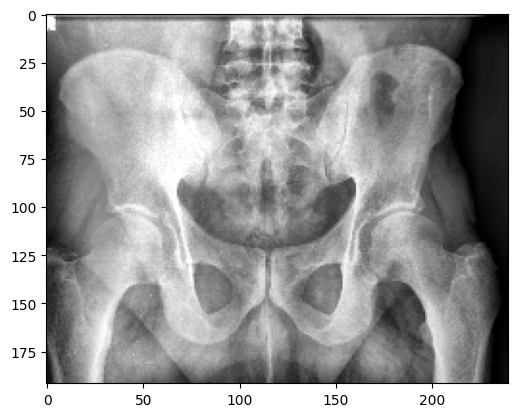

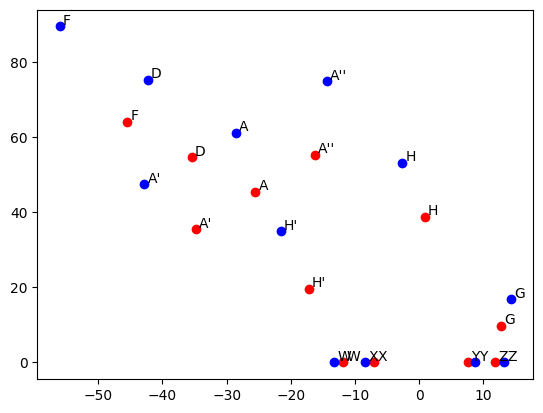

tensor([  8.1258,   7.1326,  40.2468,  46.1378,  43.3635,  77.2643,  44.8775,
        135.3465, 111.9353, 133.0896], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  8.1600,   7.6500,  45.0500,  67.0500,  48.6200, 104.0400,  44.6000,
        171.8600, 138.4200, 136.0100], device='mps:0')


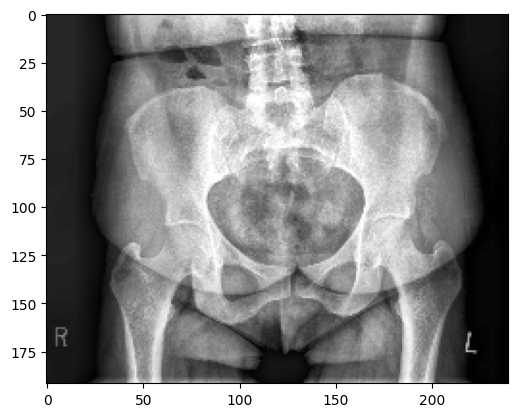

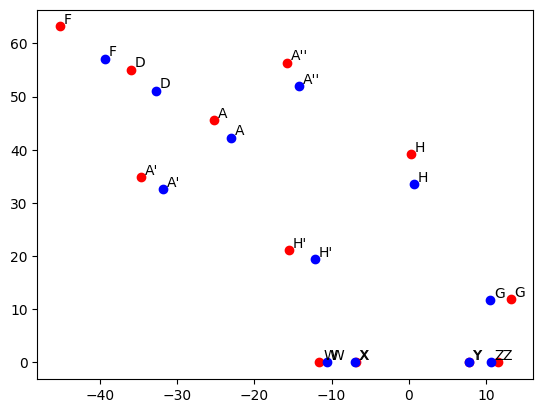

tensor([  8.0713,   6.5277,  39.3808,  48.7298,  42.8469,  77.5281,  40.7678,
        132.1744, 111.2950, 131.2800], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  6.2500,   4.7300,  36.1600,  44.6300,  39.2000,  71.8100,  32.3800,
        114.7200,  99.5100, 132.2700], device='mps:0')


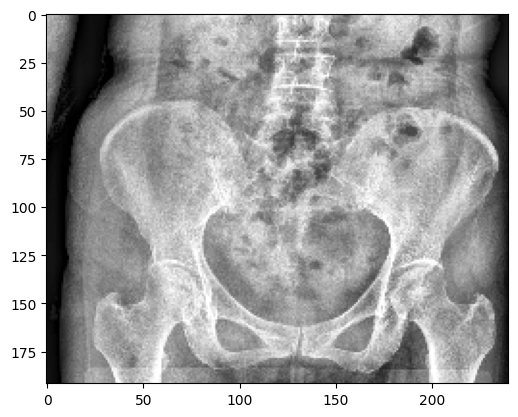

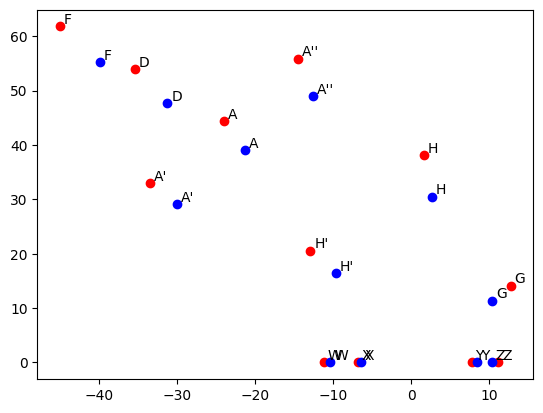

tensor([  7.3681,   5.7740,  37.9081,  50.6258,  40.6160,  75.4670,  38.7304,
        127.2237, 106.1109, 129.5306], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  6.6100,   3.2300,  35.0700,  44.9100,  36.1500,  66.3000,  31.8000,
        113.3800,  93.8500, 131.1300], device='mps:0')


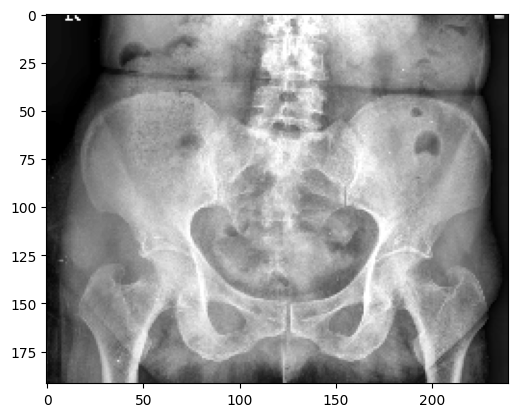

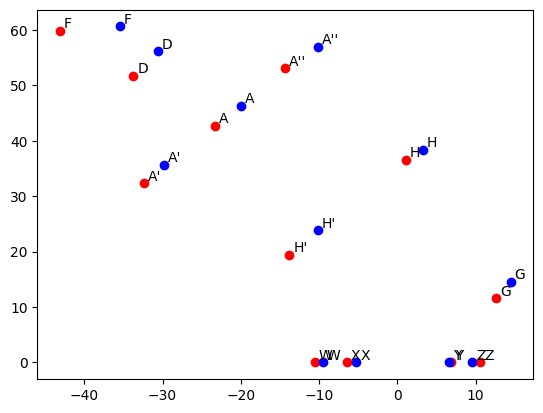

tensor([  7.0275,   6.2217,  35.9211,  46.7862,  39.6376,  72.6262,  38.5532,
        125.2690, 104.1454, 130.9049], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  7.3100,   5.1000,  32.4700,  49.2200,  33.9100,  78.7100,  33.6700,
        115.5000, 104.1900, 132.6500], device='mps:0')


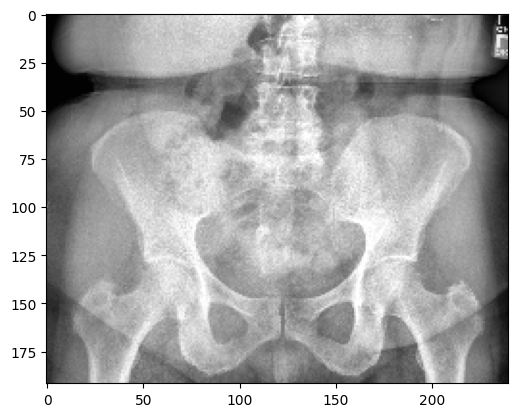

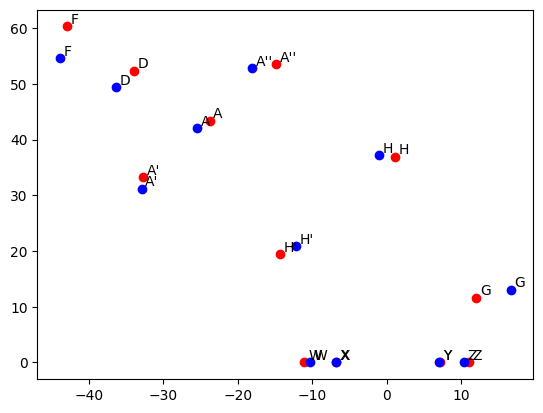

tensor([  7.2742,   6.6028,  37.5251,  45.9192,  40.4545,  73.7242,  39.6940,
        124.8784, 104.4121, 131.5104], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  6.1200,   5.6300,  35.1900,  44.5900,  43.4000,  71.4200,  33.6000,
        124.9100, 109.3100, 124.4100], device='mps:0')


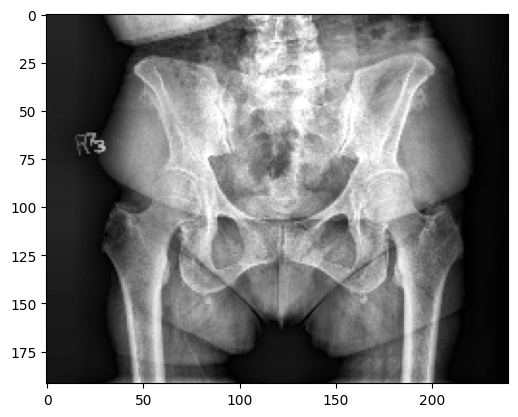

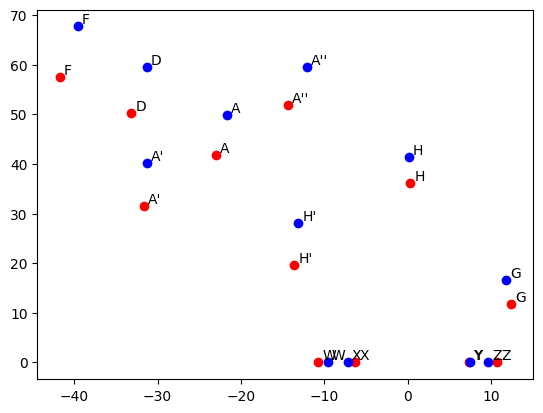

tensor([  7.5092,   5.8101,  36.5602,  45.4073,  39.0521,  70.9110,  36.5913,
        120.3307, 101.3389, 130.2196], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  4.0600,   3.7200,  32.6100,  46.2600,  36.8300,  84.8200,  31.9400,
        123.1400, 103.3800, 134.8500], device='mps:0')


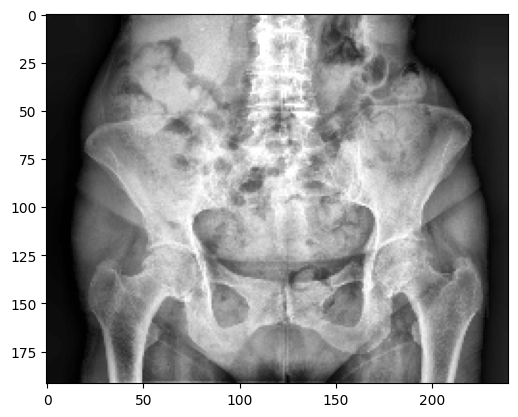

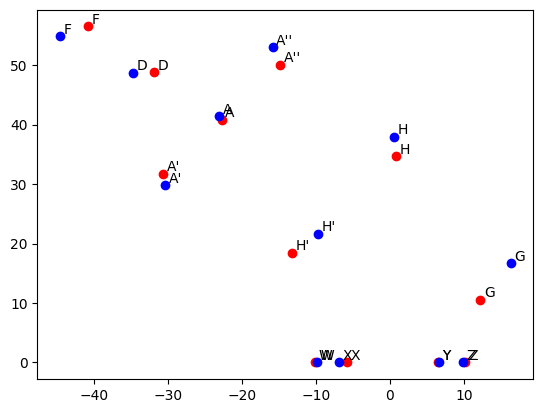

tensor([  7.2937,   6.1229,  34.5345,  41.2648,  38.7068,  69.4580,  36.5435,
        119.3364,  99.3429, 130.9126], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  5.1000,   5.6100,  33.6900,  46.5900,  39.3200,  70.3800,  32.8300,
        122.3700, 102.5100, 122.0700], device='mps:0')


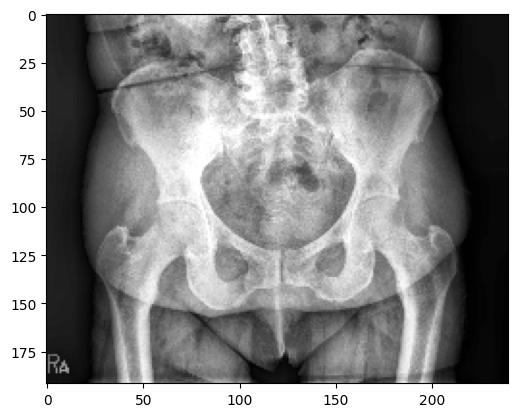

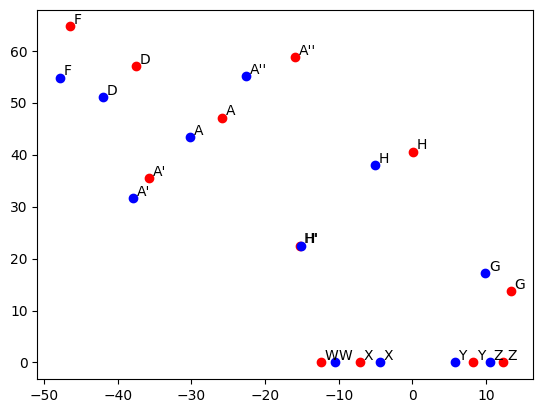

tensor([  8.8695,   7.0015,  42.0283,  51.8550,  43.9446,  80.0927,  40.3660,
        133.5623, 113.4615, 130.3949], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([ 10.4800,   8.1100,  35.8200,  47.6900,  51.3600,  73.6700,  31.4100,
        117.2200, 105.2600, 123.1000], device='mps:0')


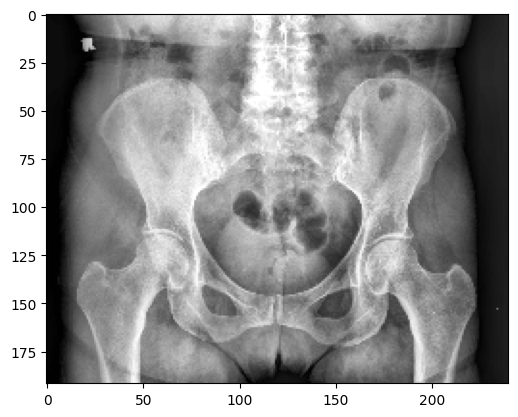

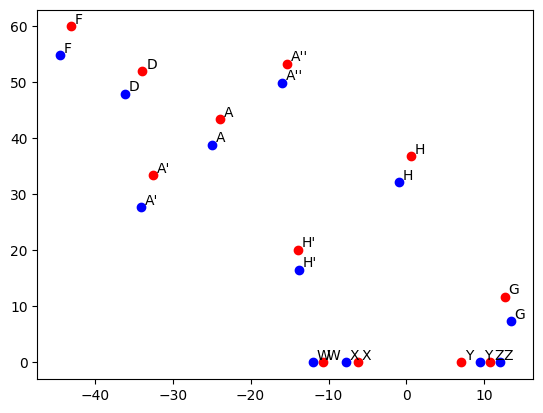

tensor([  7.7599,   6.3926,  36.6238,  44.7940,  40.6443,  73.6673,  37.4905,
        125.1060, 104.4647, 130.8826], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  7.2100,   4.3300,  40.7300,  48.7300,  42.5000,  65.9600,  34.3900,
        127.1800, 108.7600, 129.3600], device='mps:0')
Loss (out sample): 66.2841524066347

Percent error for each measurement (out sample):
0.2952 0.3320 0.0890 0.1094 0.1016 0.1215 0.1503 0.0842 0.0745 0.0345 


In [328]:
model.to(device)
model.eval()

total_loss = 0
total_percent_err = torch.zeros(10).to(device)

for images, yvals, aug_scales in test_loader:
    images = images.to(device)
    yvals = yvals.to(device)
    aug_scales = aug_scales.to(device)

    model_out = model(images)
    model_coord, ab = model_to_coord(model_out, device)
    real_coord = measurements_to_coord(yvals, ab, pix_per_mm, img_scale_factor, device)

    loss = lossfn(model_coord, real_coord, aug_scales)

    total_loss += loss.item()

    total_percent_err += torch.sum(torch.abs(yvals - coord_to_measurements(model_coord, pix_per_mm, img_scale_factor)) / yvals, dim = 0)

    plt.imshow(images[0].squeeze().detach().cpu(), cmap = 'gray')
    plt.show()

    plt.scatter(model_coord[0, :, 0].detach().cpu(), model_coord[0, :, 1].detach().cpu(), c = 'r')
    for i, label in enumerate(['A', 'D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z', 'H\'', 'A\'', 'A\'\'']):
        curx, cury = model_coord[0, i]
        plt.text(curx + 0.5, cury + 0.5, label)
    # plt.show()

    plt.scatter(real_coord[0, :, 0].detach().cpu(), real_coord[0, :, 1].detach().cpu(), c = 'b')
    for i, label in enumerate(['A', 'D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z', 'H\'', 'A\'', 'A\'\'']):
        curx, cury = real_coord[0, i]
        plt.text(curx + 0.5, cury + 0.5, label)
    plt.show()

    print(coord_to_measurements(model_coord, pix_per_mm, img_scale_factor)[0])
    print(yvals[0])

print(f'Loss (out sample): {total_loss / len(test_set)}\n')
print(f'Percent error for each measurement (out sample):')
for i in total_percent_err:
    print(f'{(i.item() / len(test_set)):.4f}', end = ' ')
print()

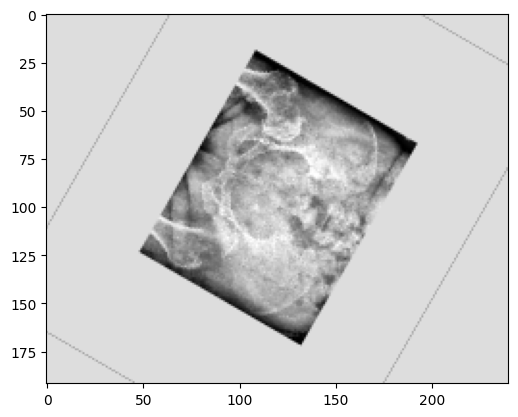

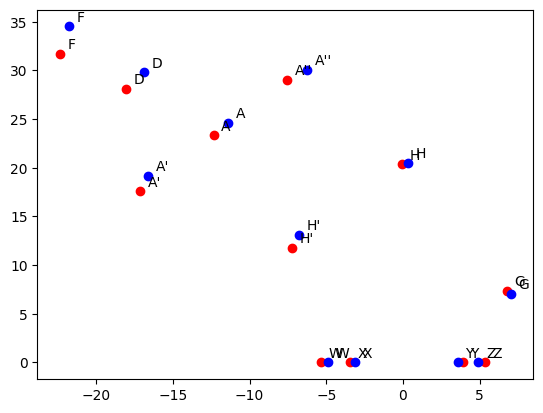

tensor([  3.2040,   2.4489,  18.1664,  25.3909,  20.9781,  39.6309,  19.0272,
         64.5681,  55.0555, 129.8602], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  3.0331,   2.2748,  16.6821,  25.5489,  19.4119,  41.8570,  17.4252,
         67.6890,  56.0975, 133.6200], device='mps:0')


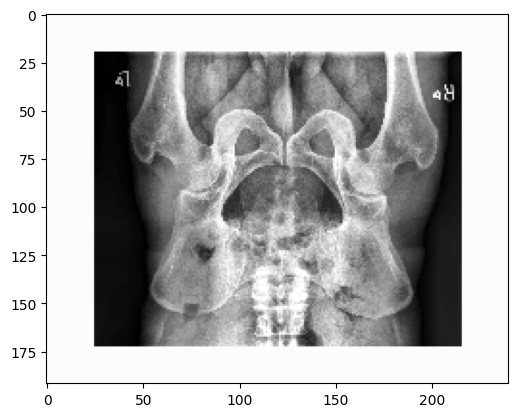

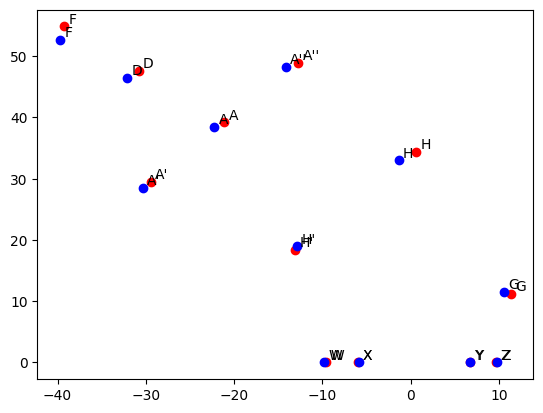

tensor([  6.2952,   4.9003,  32.7277,  43.6508,  35.8515,  66.6071,  35.6842,
        113.6027,  94.5988, 130.7142], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  6.6240,   5.1360,  33.2560,  43.4720,  37.8480,  65.2880,  30.8080,
        110.4800,  93.8160, 129.3200], device='mps:0')


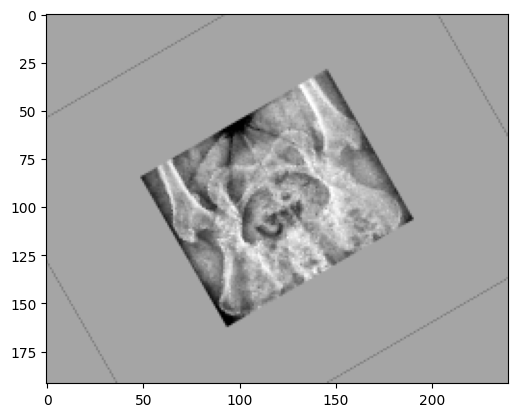

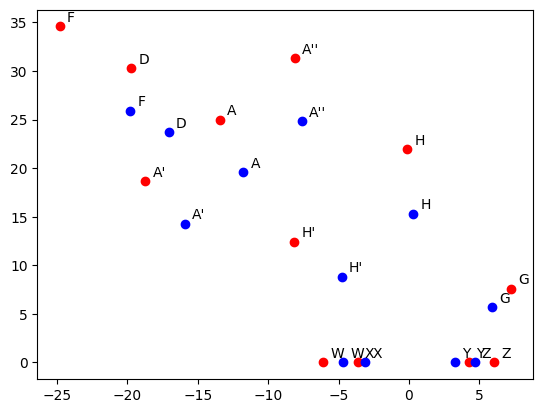

tensor([  4.1765,   3.1229,  20.6538,  28.0715,  22.7985,  42.4675,  21.1854,
         71.2239,  59.9359, 130.1122], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  2.6995,   2.4413,  15.9152,  22.8447,  19.9997,  33.2389,  13.9998,
         55.5765,  49.5907, 128.1800], device='mps:0')


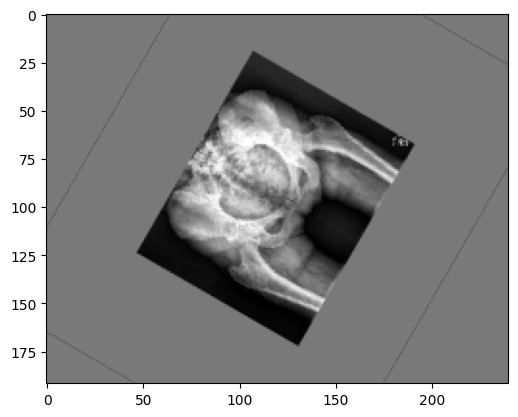

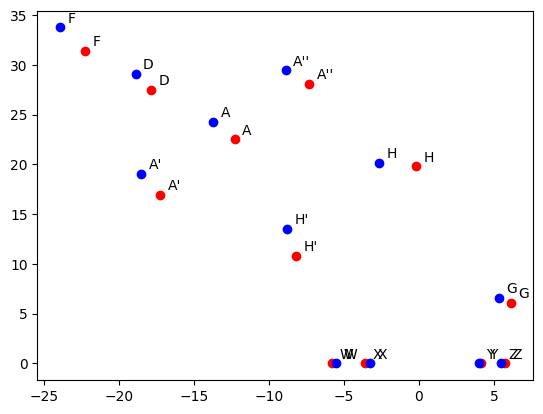

tensor([  3.6840,   2.7432,  19.6085,  25.3816,  20.9103,  38.3123,  20.5371,
         64.7263,  54.6651, 131.7056], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  3.8521,   2.5630,  18.7093,  24.0930,  23.3196,  41.2554,  15.3728,
         67.8811,  56.1733, 132.8500], device='mps:0')


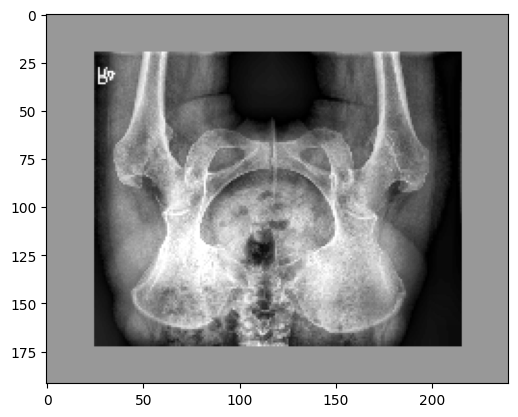

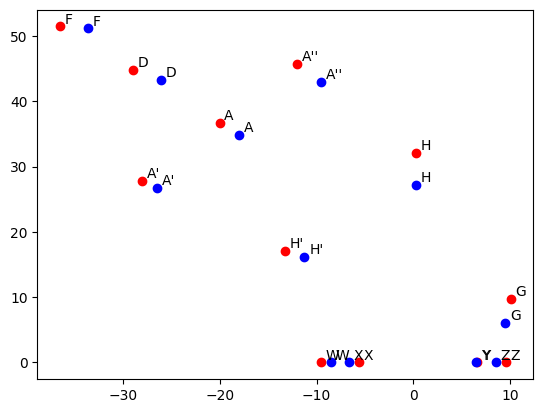

tensor([  6.6505,   5.1127,  32.4627,  40.9190,  34.0236,  62.3982,  34.2915,
        106.2534,  89.1007, 131.8721], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  3.1040,   3.4640,  28.9200,  39.7200,  30.6160,  59.2240,  27.0720,
        106.0000,  87.4800, 136.3400], device='mps:0')


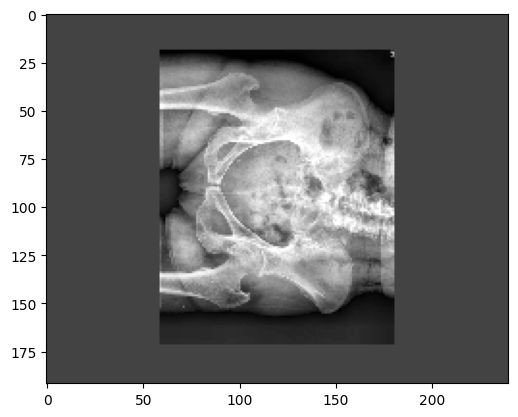

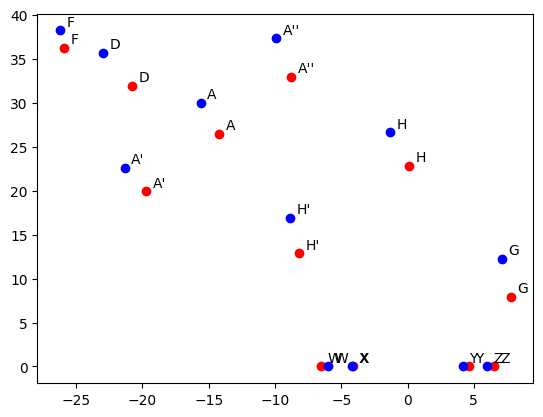

tensor([  4.1762,   3.2670,  22.2282,  28.9720,  24.2044,  44.9544,  22.0603,
         74.8241,  63.4190, 130.0562], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  3.0464,   3.1552,  20.4544,  31.6864,  26.5472,  50.9184,  20.9088,
         71.8464,  64.8384, 127.8600], device='mps:0')


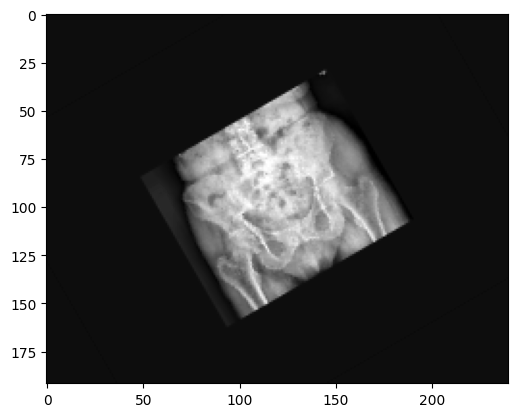

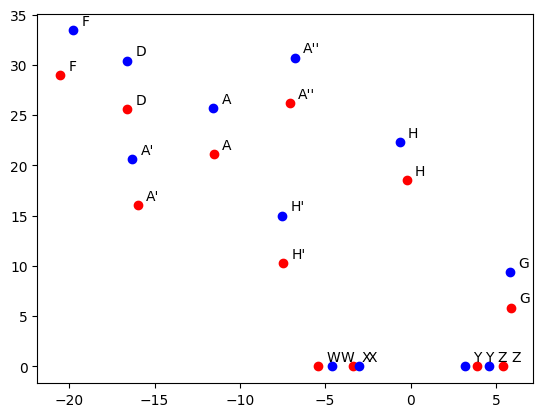

tensor([  3.5047,   2.6455,  18.4582,  22.9846,  19.6143,  35.9105,  18.6366,
         59.7230,  50.8499, 131.2226], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  2.6338,   2.3943,  15.5631,  23.5958,  19.6335,  43.6565,  17.1593,
         59.7736,  52.3231, 133.2300], device='mps:0')


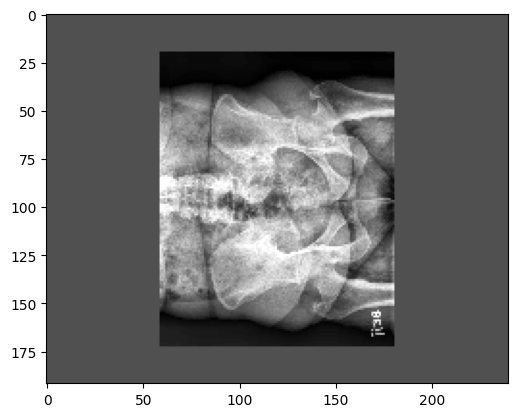

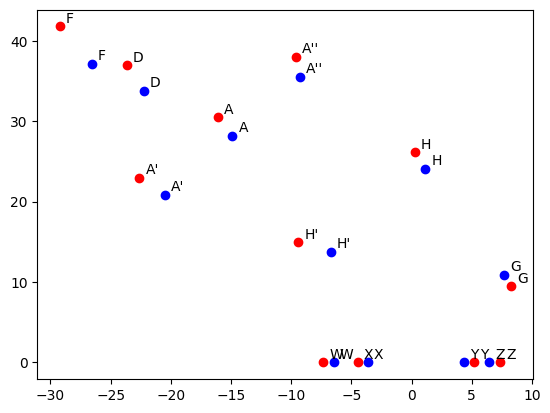

tensor([  4.9102,   3.6797,  24.9409,  33.7807,  27.3904,  51.7978,  25.1373,
         84.1090,  71.5784, 130.7871], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  4.7552,   3.5712,  21.9520,  31.3984,  25.3056,  47.9040,  21.9968,
         73.2928,  63.9488, 127.4100], device='mps:0')


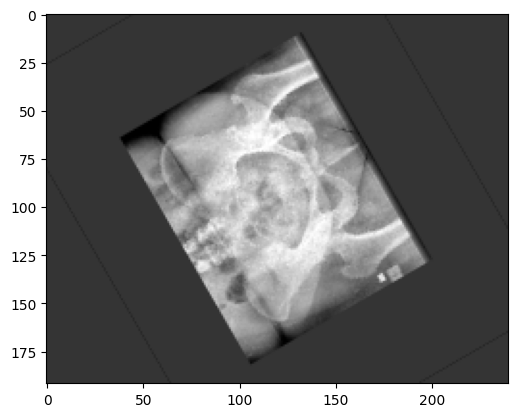

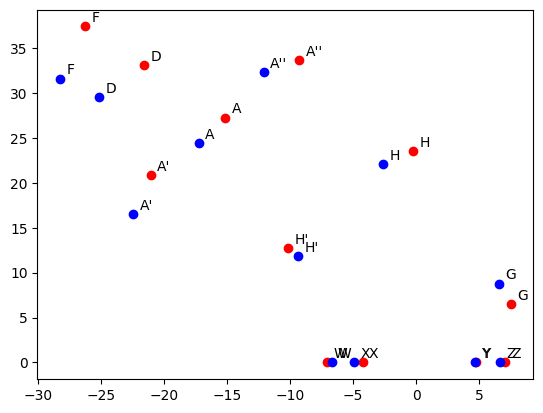

tensor([  4.8289,   3.9203,  24.0252,  29.5956,  25.7237,  46.3422,  24.9809,
         77.7677,  67.0112, 132.4911], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  2.9971,   3.3838,  22.7199,  32.1207,  29.2942,  41.4759,  20.8091,
         70.7758,  64.4688, 123.2600], device='mps:0')


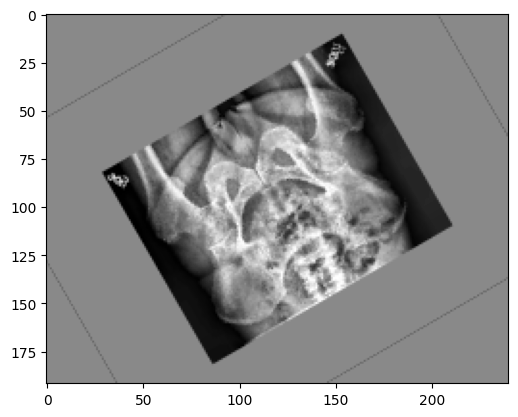

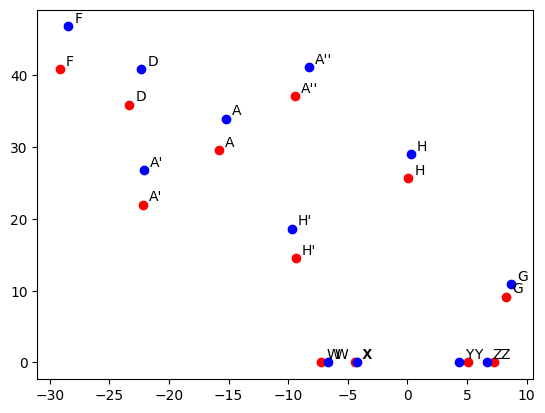

tensor([  4.9510,   3.7825,  24.7564,  33.5760,  26.8436,  50.2040,  24.9065,
         83.3453,  70.3831, 130.2579], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  4.0925,   3.8933,  22.6113,  33.7419,  25.8044,  57.7234,  24.4463,
         87.8194,  73.3026, 134.0700], device='mps:0')
Loss (out sample): 5.487323770843427

Percent error for each measurement (out sample):
0.0284 0.0258 0.0096 0.0073 0.0105 0.0102 0.0150 0.0075 0.0064 0.0030 


In [329]:
model.to(device)
model.eval()

total_loss = 0
total_percent_err = torch.zeros(10).to(device)

print_count = 10 #how many in sample to show

for images, yvals, aug_scales in train_loader:
    images = images.to(device)
    yvals = yvals.to(device)
    aug_scales = aug_scales.to(device)

    model_out = model(images)
    model_coord, ab = model_to_coord(model_out, device)
    real_coord = measurements_to_coord(yvals, ab, pix_per_mm, img_scale_factor, device)

    loss = lossfn(model_coord, real_coord, aug_scales)

    total_loss += loss.item()

    total_percent_err += torch.sum(torch.abs(yvals - coord_to_measurements(model_coord, pix_per_mm, img_scale_factor)) / yvals, dim = 0)

    plt.imshow(images[0].squeeze().detach().cpu(), cmap = 'gray')
    plt.show()

    plt.scatter(model_coord[0, :, 0].detach().cpu(), model_coord[0, :, 1].detach().cpu(), c = 'r')
    for i, label in enumerate(['A', 'D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z', 'H\'', 'A\'', 'A\'\'']):
        curx, cury = model_coord[0, i]
        plt.text(curx + 0.5, cury + 0.5, label)
    # plt.show()

    plt.scatter(real_coord[0, :, 0].detach().cpu(), real_coord[0, :, 1].detach().cpu(), c = 'b')
    for i, label in enumerate(['A', 'D', 'F', 'G', 'H', 'W', 'X', 'Y', 'Z', 'H\'', 'A\'', 'A\'\'']):
        curx, cury = real_coord[0, i]
        plt.text(curx + 0.5, cury + 0.5, label)
    plt.show()

    print(coord_to_measurements(model_coord, pix_per_mm, img_scale_factor)[0])
    print(yvals[0])

    print_count -= 1;
    if print_count == 0:
        break

print(f'Loss (out sample): {total_loss / len(train_set)}\n')
print(f'Percent error for each measurement (out sample):')
for i in total_percent_err:
    print(f'{(i.item() / len(train_set)):.4f}', end = ' ')
print()